In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import itertools
import seaborn as sns

# -------- reproducibility & device --------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# -------- hyperparams --------
batch_size = 128
epochs = 12
lr = 1e-3
model_save_path = Path("cnn_mnist.pth")

# -------- data (normalized as usual for MNIST) --------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_ds   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train size: {len(train_ds)}  Val size: {len(val_ds)}  Batch size: {batch_size}")


Train size: 60000  Val size: 10000  Batch size: 128


In [4]:
# -------- model: small, clean CNN --------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2,2)                            # 28 -> 14 -> 7 after two pools
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, num_classes)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)             # 14x14
        x = self.dropout1(x)
        x = self.pool(x)             # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x
    def encode(self, x):
        # optional: features from just before classifier
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return x

# -------- training / eval helpers --------
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += float(loss.item()) * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return running_loss / total, correct / total, all_preds, all_targets


In [5]:
# -------- instantiate --------
model = SmallCNN(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.5)

# -------- training loop --------
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
start = datetime.now()
for ep in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    scheduler.step()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": ep, "history": history}, model_save_path)
    print(f"Epoch {ep:02d}/{epochs}  Train loss: {tr_loss:.4f}, acc: {tr_acc*100:.2f}%  Val loss: {val_loss:.4f}, acc: {val_acc*100:.2f}%")
end = datetime.now()
print("Training finished — elapsed:", end - start)
print(f"Best val accuracy: {best_val_acc*100:.2f}%  (model saved to {model_save_path})")

# -------- final evaluation & confusion matrix --------
val_loss, val_acc, all_preds, all_targets = evaluate(model, val_loader, criterion, device)
print(f"\nFinal eval: Val loss: {val_loss:.4f}  Val acc: {val_acc*100:.2f}%")


Epoch 01/12  Train loss: 0.2790, acc: 91.40%  Val loss: 0.0583, acc: 98.09%
Epoch 02/12  Train loss: 0.1006, acc: 96.97%  Val loss: 0.0404, acc: 98.70%
Epoch 03/12  Train loss: 0.0836, acc: 97.48%  Val loss: 0.0340, acc: 98.84%
Epoch 04/12  Train loss: 0.0704, acc: 97.88%  Val loss: 0.0332, acc: 98.88%
Epoch 05/12  Train loss: 0.0640, acc: 98.06%  Val loss: 0.0305, acc: 98.90%
Epoch 06/12  Train loss: 0.0555, acc: 98.35%  Val loss: 0.0298, acc: 99.04%
Epoch 07/12  Train loss: 0.0420, acc: 98.68%  Val loss: 0.0256, acc: 99.25%
Epoch 08/12  Train loss: 0.0385, acc: 98.83%  Val loss: 0.0249, acc: 99.17%
Epoch 09/12  Train loss: 0.0372, acc: 98.84%  Val loss: 0.0238, acc: 99.17%
Epoch 10/12  Train loss: 0.0330, acc: 98.97%  Val loss: 0.0255, acc: 99.14%
Epoch 11/12  Train loss: 0.0313, acc: 99.02%  Val loss: 0.0244, acc: 99.25%
Epoch 12/12  Train loss: 0.0324, acc: 98.98%  Val loss: 0.0245, acc: 99.25%
Training finished — elapsed: 0:02:14.760834
Best val accuracy: 99.25%  (model saved to c

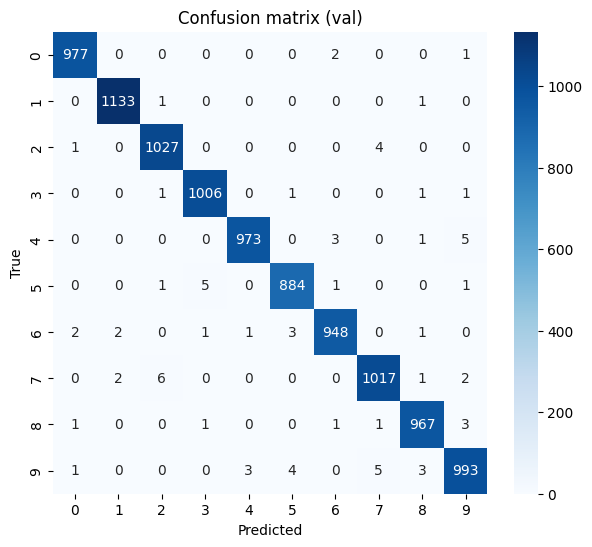


Per-class accuracy:
 0: 99.69%  / 980
 1: 99.82%  / 1135
 2: 99.52%  / 1032
 3: 99.60%  / 1010
 4: 99.08%  / 982
 5: 99.10%  / 892
 6: 98.96%  / 958
 7: 98.93%  / 1028
 8: 99.28%  / 974
 9: 98.41%  / 1009


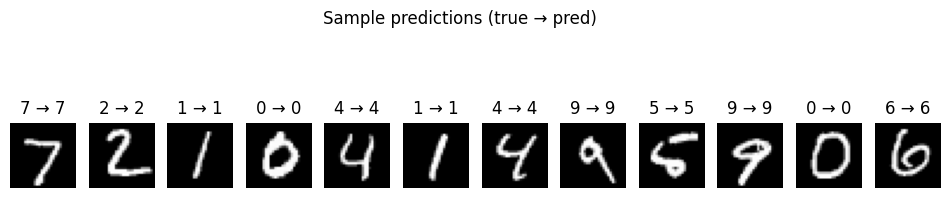

CNN val features shape: torch.Size([10000, 128])
Saved: cnn_mnist.pth (best), cnn_features.pt


In [6]:
# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (val)")
plt.show()

# per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
print("\nPer-class accuracy:")
for i, a in enumerate(per_class_acc):
    print(f" {i}: {a*100:.2f}%  / {cm[i].sum()}")

# -------- sample predictions --------
def show_sample_preds(model, dataset, device, n=12):
    model.eval()
    imgs = []
    trues = []
    preds = []
    # pick first n images
    for i in range(n):
        img, lbl = dataset[i]
        imgs.append(img)
        trues.append(int(lbl))
    xb = torch.stack(imgs, dim=0).to(device)
    with torch.no_grad():
        logits = model(xb)
        pred_labels = logits.argmax(dim=1).cpu().numpy()
    plt.figure(figsize=(12,3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        # undo normalization for display
        im = imgs[i].squeeze(0).numpy() * 0.3081 + 0.1307
        im = np.clip(im, 0, 1)
        plt.imshow(im, cmap='gray')
        plt.title(f"{trues[i]} → {pred_labels[i]}")
        plt.axis('off')
    plt.suptitle("Sample predictions (true → pred)")
    plt.show()

show_sample_preds(model, val_ds, device, n=12)

# -------- optional: extract CNN encoder features (for comparison later) --------
# Example: extract penultimate-layer features for validation set
def extract_cnn_features(model, dataloader, device, max_batches=None):
    model.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for i, (xb, yb) in enumerate(dataloader):
            xb = xb.to(device)
            f = model.encode(xb)
            feats.append(f.cpu())
            labels.append(yb)
            if (max_batches is not None) and (i+1 >= max_batches):
                break
    feats = torch.cat(feats, dim=0)
    labels = torch.cat(labels, dim=0)
    return feats, labels

val_feats, val_labels = extract_cnn_features(model, val_loader, device, max_batches=None)
print("CNN val features shape:", val_feats.shape)

# saved artifacts: cnn_mnist.pth (model) and cnn_features.pt (features)
torch.save({"val_feats": val_feats, "val_labels": val_labels}, "cnn_features.pt")
print("Saved: cnn_mnist.pth (best), cnn_features.pt")